There be a baseline pretrained models that be fine-tuned on my own mini-dataset(models like YOLO SSD R-CNN etc.)

In [350]:
import torch
from torch import nn
from matplotlib import pyplot as plt

N_EPOCHS = 10
BATCH_SIZE = 1
LR_RATE = 1e-4
WEIGHT_DECAY = 1e-5
SEED = 42
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def seed_all(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(SEED)

Dataset and loader

In [351]:
def data_transform(x):
    x = x/255
    x = torch.tensor(x,dtype=torch.float32)
    x = x.permute(2,0,1)
    return x

def label_transform(x):
    x = torch.tensor(x,dtype=torch.float32)
    return x

In [352]:
from torch.utils.data import Dataset,DataLoader,random_split
import json
import os
import cv2

class MyDataset(Dataset):
    def __init__(self,folder_path,json_path,data_transforms=None,label_transforms=None,resolution=None):

        self.data_transforms = data_transforms
        self.label_transforms = label_transforms
        self.resolution = resolution

        with open(json_path,'r',encoding='utf-8') as f:
            self.data_dict = json.load(f)

        self.images = [ (os.path.join(folder_path,path),cords) for path,cords in self.data_dict.items() ]  
        self.length = len(self.images)

    def __getitem__(self, item):
        value = self.images[item]
        path,label = value

        image = cv2.imread(path)
        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        if self.resolution:
            image = cv2.resize(image,self.resolution)

        if self.data_transforms:
            image = self.data_transforms(image)

        if self.label_transforms:
            label = self.label_transforms(label)

        return image,label

    def __len__(self,):
        return self.length


folder_path = 'FacesDetectionDataset'
json_path = 'FacesDetectionDataset/labels.json'

data = MyDataset(folder_path,json_path,data_transforms=data_transform,label_transforms=label_transform)

train_data,test_data = random_split(data,[0.8,0.2])
train_data,validation_data = random_split(train_data,[0.9,0.1])

train = DataLoader(train_data,BATCH_SIZE,shuffle=True,drop_last=True)
validation = DataLoader(validation_data,BATCH_SIZE,shuffle=False,drop_last=False)
test = DataLoader(test_data,BATCH_SIZE,shuffle=False,drop_last=False)


Model

In [353]:
class BasicBlock(nn.Module):
    def __init__(self,input_channels,output_channels,hidden_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(input_channels,hidden_channels,3,padding='same',bias=False)
        self.conv2 = nn.Conv2d(hidden_channels,output_channels,3,padding='same',bias=False)

        self.relu = nn.ReLU()
        self.batch_norm = nn.BatchNorm2d(output_channels)

        self.pooling = nn.MaxPool2d(2)

    def forward(self,x: torch.Tensor):
        x = self.conv1(x)
        x = self.conv2(x)

        #x = self.relu(x)
        x = self.batch_norm(x)

        return self.pooling(x)

class FC(nn.Module):
    def __init__(self,input_features,output_features,hidden_features,hidden_channels):
        super().__init__()

        self.lin1 = nn.Linear(input_features,hidden_features,bias=False)
        self.lin2 = nn.Linear(hidden_features,output_features,bias=False)

        self.relu = nn.ReLU()
        self.batch_norm = nn.BatchNorm1d(hidden_channels)

    def forward(self,x: torch.Tensor):
        x = self.lin1(x)
        x = self.lin2(x)

        x = self.batch_norm(x)
        #x = self.relu(x)
        return x
    
class BasicModel(nn.Module):
    def __init__(self,hidden_dim=64,max_objects=100,res=[1920,1080],adaptive_shape=32):
        super().__init__()

        self.res = res
        self.max_objects = max_objects
        self.hidden_dim = hidden_dim
        self.adaptive_shape = adaptive_shape

        self.conv1 = BasicBlock(3,3,3)
        self.conv2 = BasicBlock(3,3,3)
        self.conv3 = BasicBlock(3,self.max_objects,self.hidden_dim)

        self.pooling = nn.AdaptiveAvgPool2d(self.adaptive_shape)

        self.lin1 = FC((self.adaptive_shape//2)**2,5,128,hidden_channels=max_objects) # B self.max_objects (x y w h conf)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self,x: torch.Tensor,conf=.7):
        B,_,_,_ = x.shape

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.pooling(x)
        x = self.conv3(x) # B self.max_objects self.adaptive_shape

        x = x.reshape(B,self.max_objects,-1)

        x = self.lin1(x)
        x[x<0] = 0
        #x = self.relu(x)

        x[:,:,4] = self.sigmoid(x[:,:,4])


        x_1 = x.clone()
        x = x[None,x[:,:,4] >= conf]
        if x.shape[1] == 0:
            x = x_1[:,x_1[:,:,4].argmax().item()]
            x = torch.unsqueeze(x,dim=0)

        #x[:,:,[0,2]] *= self.res[0] # w
        #x[:,:,[1,3]] *= self.res[1] # h

        x = torch.round(x)

        x[x[:,:,0] > self.res[0]] = self.res[0]
        x[x[:,:,2] > self.res[0]] = self.res[0]
        x[x[:,:,1] > self.res[1]] = self.res[1]
        x[x[:,:,3] > self.res[1]] = self.res[1]
        
        
        return x[:,:,:4]



Loss func

In [354]:
class CustomLoss(nn.Module):
    def __init__(self,loss_reducing=1):
        super().__init__()
        self.loss_reducing = loss_reducing
    
    def forward(self,pred: torch.Tensor,label: torch.Tensor):
        _,o1,c1 = pred.shape # (batch, objects, cordinates)
        _,o2,c2 = label.shape # (batch, objects, cordinates)

        obj_coef = abs(o2-o1)
        if o1 >= o2:
            result = (((pred[:,:o2,:] - label)**2).sum(dim=2)).sum(dim=1) * obj_coef * self.loss_reducing
        else:
            result = (((pred - label[:,:o1,:])**2).sum(dim=2)).sum(dim=1) * obj_coef * self.loss_reducing
        result /= (label**2).sum(dim=2).sum(dim=1)
        return result

Learning_Cycle

In [355]:
from torch import optim

torch.autograd.set_detect_anomaly(True)

model = BasicModel()
model.to(DEVICE)
optimizer = optim.NAdam(model.parameters(),lr=LR_RATE,weight_decay=WEIGHT_DECAY)
criterion = CustomLoss()

validation_all_losses = []
train_all_losses = []

for epoch in range(1,N_EPOCHS+1):
    train_epoch_losses = []
    validation_epoch_losses = []

    model.train()
    for image,label in train:
        image,label = image.to(DEVICE),label.to(DEVICE)

        optimizer.zero_grad()

        pred = model(image,0.5)
        loss = criterion(pred,label)

        loss.backward()
        optimizer.step()

        train_epoch_losses.append(round(loss.item(),2))

    model.eval()
    for image,label in validation:
        image,label = image.to(DEVICE),label.to(DEVICE)

        with torch.no_grad():
            pred = model(image)
            loss = criterion(pred,label)

        validation_epoch_losses.append(round(loss.item(),2))

    train_all_losses.extend(train_epoch_losses)
    validation_all_losses.extend(validation_epoch_losses)

    print(f'Epoch losses: {epoch} Train: {round(sum(train_epoch_losses)/len(train),2)}, Validation: {round(sum(validation_epoch_losses)/len(validation),2)}')

Epoch losses: 1 Train: 97.25, Validation: 24.04
Epoch losses: 2 Train: 97.28, Validation: 0.28
Epoch losses: 3 Train: 97.33, Validation: 0.23
Epoch losses: 4 Train: 97.33, Validation: 0.23
Epoch losses: 5 Train: 97.33, Validation: 0.23
Epoch losses: 6 Train: 97.33, Validation: 0.23
Epoch losses: 7 Train: 97.33, Validation: 0.23
Epoch losses: 8 Train: 97.33, Validation: 0.23
Epoch losses: 9 Train: 97.33, Validation: 0.23
Epoch losses: 10 Train: 97.33, Validation: 0.23


Saving model weights

In [356]:
state_dict = model.state_dict()
torch.save(state_dict,f'Trained_Weights/Basemodel{N_EPOCHS}epochs_weights.tar')

Drawing Train and Validation Scores

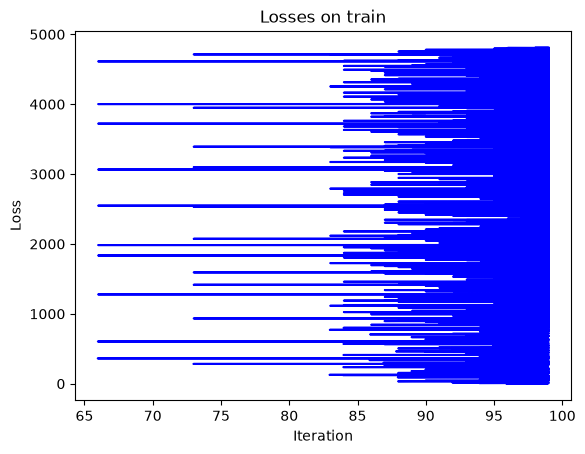

In [357]:
plt.plot(train_all_losses,list(range(N_EPOCHS*len(train))),color='blue')
plt.title('Losses on train')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

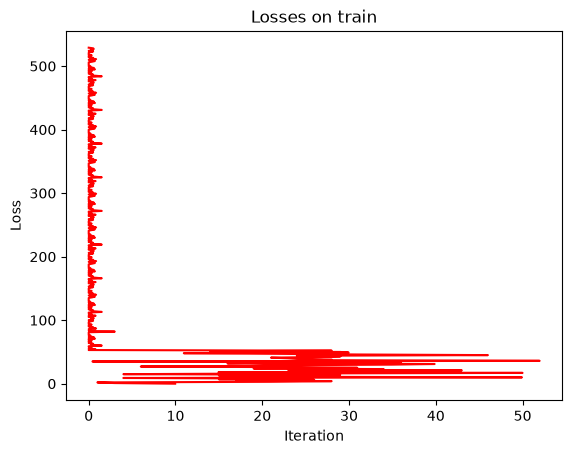

In [358]:
plt.plot(validation_all_losses,list(range(N_EPOCHS*len(validation))),color='red')
plt.title('Losses on train')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()

Evaluate

In [359]:
t1 = torch.ones((3,3,3))
t1.argmax()


tensor(0)